# Video load

In [1]:
import cv2

video_path = "14498462_540_960_30fps.mp4"
cap = cv2.VideoCapture(video_path)

cap.isOpened()

True

In [28]:
ret, frame = cap.read()
print(ret)
print(frame)

False
None


In [6]:
try:
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        cv2.imshow("Video", frame)
        if cv2.waitKey(25) & 0xFF == ord('q'):
            break
finally:
    cap.release()
    cv2.destroyAllWindows()
    cv2.waitKey(1)

# Single frame

Frame shape: (960, 540, 3)


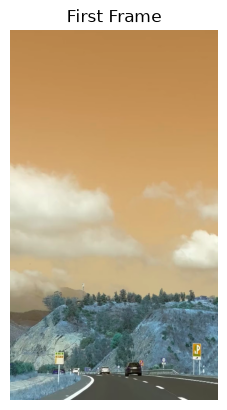

In [ ]:
import cv2
import matplotlib.pyplot as plt

video_path = "14498462_540_960_30fps.mp4"
cap = cv2.VideoCapture(video_path)

ret, frame = cap.read()

if ret:
    print("Frame shape:", frame.shape)   # (H, W, C)

    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB) # BGR dan RGB o'tqaziladi
    plt.imshow(frame)
    # plt.imshow(frame_rgb)
    plt.title("First Frame")
    plt.axis("off")
    plt.show()
else:
    print("Frame o‘qilmadi")

cap.release()

In [13]:
video_path = "14498462_540_960_30fps.mp4"
cap = cv2.VideoCapture(video_path)

print(cap.get(cv2.CAP_PROP_POS_FRAMES))        # hozirgi kadr raqami
print(cap.get(cv2.CAP_PROP_FRAME_COUNT))       # jami kadrlar soni

0.0
496.0


Frame shape: (960, 540, 3)


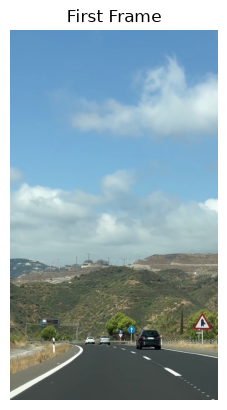

In [20]:
import cv2
import matplotlib.pyplot as plt

video_path = "14498462_540_960_30fps.mp4"
cap = cv2.VideoCapture(video_path)

cap.set(cv2.CAP_PROP_POS_FRAMES, 495)
ret, frame = cap.read()

if ret:
    print("Frame shape:", frame.shape)   # (H, W, C)

    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB) # BGR dan RGB o'tqaziladi
    # plt.imshow(frame)
    plt.imshow(frame_rgb)
    plt.title("First Frame")
    plt.axis("off")
    plt.show()
else:
    print("Frame o‘qilmadi")

cap.release()

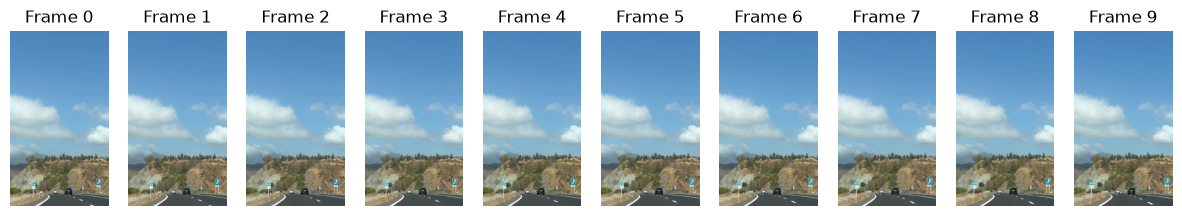

In [23]:
import cv2
import matplotlib.pyplot as plt

video_path = "14498462_540_960_30fps.mp4"
cap = cv2.VideoCapture(video_path)

n = 10  # nechta kadr kerak
frames = []

for i in range(n):
    ret, frame = cap.read()
    if not ret:
        print("Video tugadi")
        break
    frames.append(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))

cap.release()

plt.figure(figsize=(15, 5))
for i, f in enumerate(frames):
    plt.subplot(1, len(frames), i + 1)
    plt.imshow(f)
    plt.title(f"Frame {i}")
    plt.axis("off")
plt.show()

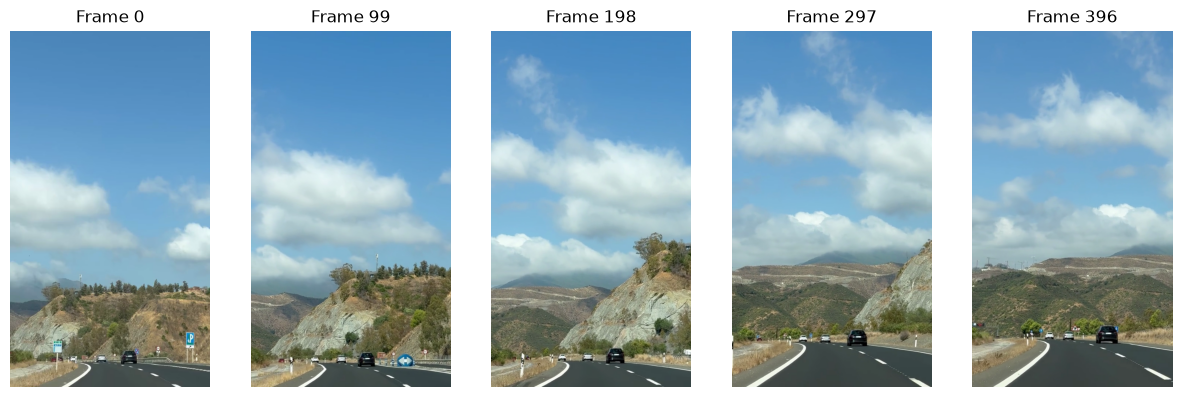

In [24]:
import cv2
import matplotlib.pyplot as plt

cap = cv2.VideoCapture("14498462_540_960_30fps.mp4")

total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
n = 5
indices = [int(i * total / n) for i in range(n)]  # teng oraliqdagi kadr raqamlari

frames = []
for idx in indices:
    cap.set(cv2.CAP_PROP_POS_FRAMES, idx)  # shu kadrga sakrash
    ret, frame = cap.read()
    if ret:
        frames.append((idx, cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)))

cap.release()

plt.figure(figsize=(15, 6))
for i, (idx, f) in enumerate(frames):
    plt.subplot(1, len(frames), i + 1)
    plt.imshow(f)
    plt.title(f"Frame {idx}")
    plt.axis("off")
plt.show()

In [25]:
import cv2

cap = cv2.VideoCapture("14498462_540_960_30fps.mp4")

fps = cap.get(cv2.CAP_PROP_FPS)
total = cap.get(cv2.CAP_PROP_FRAME_COUNT)

print("FPS:", fps)
print("Jami kadrlar:", int(total))
print("Davomiyligi (sekund):", total / fps)

cap.release()

FPS: 30.0
Jami kadrlar: 496
Davomiyligi (sekund): 16.533333333333335


In [26]:
import cv2

cap = cv2.VideoCapture("14498462_540_960_30fps.mp4")


width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

print("Resolution:", width, "x", height)

cap.release()

Resolution: 540 x 960


In [ ]:
# ===== cv2.VideoCapture obyekti (cap) metodlari =====

cap = cv2.VideoCapture("video.mp4")   # video faylni ochadi (0 yozilsa, kamera)
cap.isOpened()                        # ochilganmi? True/False qaytaradi
ret, frame = cap.read()               # keyingi kadrni o'qiydi; ret: True/False, frame: kadr
cap.get(cv2.CAP_PROP_FPS)             # qiymatini o'qiydi
cap.set(cv2.CAP_PROP_POS_FRAMES, 100) # qiymatini o'zgartiradi
cap.release()                         # videoni yoki kamerani bo'shatadi


# ===== cv2 funksiyalari =====

cv2.imshow("Video", frame)            # kadrni oynada ko'rsatadi
cv2.waitKey(25)                       # 25 ms kutadi, bosilgan tugma kodini qaytaradi
cv2.waitKey(25) & 0xFF == ord('q')    # 'q' bosilganini tekshiradi
cv2.destroyAllWindows()               # barcha OpenCV oynalarini yopadi
cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)  # rang formatini BGR dan RGB ga o'giradi

# ===== PROPS =====

cv2.CAP_PROP_POS_FRAMES    # hozirgi kadr ko'rsatkichi (get va set)
cv2.CAP_PROP_FRAME_COUNT   # jami kadrlar soni (get)
cv2.CAP_PROP_FPS           # sekundiga kadrlar soni (get)
cv2.CAP_PROP_FRAME_WIDTH   # kadr kengligi (piksel)
cv2.CAP_PROP_FRAME_HEIGHT  # kadr balandligi (piksel)
cv2.CAP_PROP_POS_MSEC      # hozirgi o'rin (millisekundda)
